In [1]:
!pip install qiskit
!pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.4 MB/s eta 0:00:00


In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import itertools
import math

In [3]:
#Task 1 — Modify the Oracle
def oracle_constant(qc, ancilla, value=0):
    if value == 1:
        qc.x(ancilla)


def oracle_balanced_firstbit(qc, inputs, ancilla):
    qc.cx(inputs[0], ancilla)


def oracle_balanced_arbitrary_half(qc, inputs, ancilla, half_subset=None):
    n = len(inputs)
    if half_subset is None:
        half_subset = set(range(2**(n-1), 2**n))
    else:
        half_subset = set(half_subset)


    for x in sorted(half_subset):

        bits = [(x >> i) & 1 for i in range(n)]  # LSB-first; inputs index assumed 0..n-1

        for i, b in enumerate(bits):
            if b == 0:
                qc.x(inputs[i])

        qc.mcx(inputs, ancilla)
        for i, b in enumerate(bits):
            if b == 0:
                qc.x(inputs[i])

In [4]:
def deutsch_jozsa_circuit(n, oracle_func, oracle_args=()):

    qreg = QuantumRegister(n + 1, "q")
    creg = ClassicalRegister(n, "c")
    qc = QuantumCircuit(qreg, creg)

    inputs = list(range(n))
    ancilla = n
    qc.x(ancilla)
    qc.h(qreg)
    oracle_func(qc, inputs, ancilla, *oracle_args)
    for q in inputs:
        qc.h(q)
    qc.measure(inputs, creg)

    return qc

In [8]:
def run_on_simulator(qc, shots=1024, noise_model=None):

    simulator = AerSimulator()
    tqc = transpile(qc, simulator)
    if noise_model:
        backend = simulator
        job = backend.run(tqc, shots=shots, noise_model=noise_model)
    else:
        job = simulator.run(tqc, shots=shots)
    result = job.result()
    counts = result.get_counts()
    return counts

def analyze_and_plot(qc, counts, title=""):
    print("Circuit depth:", qc.depth())
    print(qc.draw(fold=-1))
    print("Counts:", counts)
    plot_histogram(counts)
    plt.title(title)
    plt.show()
    n = qc.num_clbits
    if counts.get("0" * n, 0) == sum(counts.values()):
        print("✅ Measured all zeros => Function is CONSTANT")
    else:
        print("✅ Not all zeros => Function is BALANCED")

In [12]:
def demo_various_n():
    for n in [2, 4, 5]:
        print("\n" + "="*30)
        print(f"DEUTSCH-JOZSA, n = {n} inputs — Balanced (first-bit) oracle")
        qc = deutsch_jozsa_circuit(n, oracle_balanced_firstbit)
        counts = run_on_simulator(qc, shots=1024)
        analyze_and_plot(qc, counts, title=f"Balanced (first-bit) n={n}")

def demo_arbitrary_half_oracle(n=3):

    subset = {1, 4, 5, 6} if n==3 else None
    qc = deutsch_jozsa_circuit(n, oracle_balanced_arbitrary_half, oracle_args=(subset,))
    counts = run_on_simulator(qc, shots=1024)
    analyze_and_plot(qc, counts, title=f"Arbitrary half-subset oracle n={n}")
from qiskit_aer.noise import NoiseModel, depolarizing_error

def demo_noise_model(n=3):

    noise_model = NoiseModel()
    p1 = 0.005  # single-qubit depolarizing probability
    p2 = 0.01   # two-qubit depolarizing probability
    p3 = 0.02   # three-qubit depolarizing probability


    single_err = depolarizing_error(p1, 1)
    two_err = depolarizing_error(p2, 2)
    three_err = depolarizing_error(p3, 3)

    # Add noise for gates by their number of qubits
    noise_model.add_all_qubit_quantum_error(single_err, ['h', 'x'])
    noise_model.add_all_qubit_quantum_error(two_err, ['cx'])
    noise_model.add_all_qubit_quantum_error(three_err, ['ccx'])


    print("\n--- Running with noise model ---")
    qc = deutsch_jozsa_circuit(n, oracle_balanced_firstbit)
    counts = run_on_simulator(qc, shots=2048, noise_model=noise_model)
    analyze_and_plot(qc, counts, title=f"Noisy simulation n={n}")
    return noise_model

# Print unitary / gate definition of an oracle
def print_oracle_gate_definition(n, oracle_func, oracle_args=()):

    qreg = QuantumRegister(n + 1, "q")
    qc = QuantumCircuit(qreg)
    inputs = list(range(n))
    ancilla = n
    oracle_func(qc, inputs, ancilla, *oracle_args)

    oracle_gate = qc.to_gate(label="Oracle")
    print("Oracle gate definition (decomposition):")
    print(oracle_gate.definition)


DEUTSCH-JOZSA, n = 2 inputs — Balanced (first-bit) oracle
Circuit depth: 5
     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐  │  └┬─┬┘└╥┘
q_1: ┤ H ├┤ H ├──┼───┤M├──╫─
     ├───┤├───┤┌─┴─┐ └╥┘  ║ 
q_2: ┤ X ├┤ H ├┤ X ├──╫───╫─
     └───┘└───┘└───┘  ║   ║ 
c: 2/═════════════════╩═══╩═
                      1   0 
Counts: {'01': 1024}


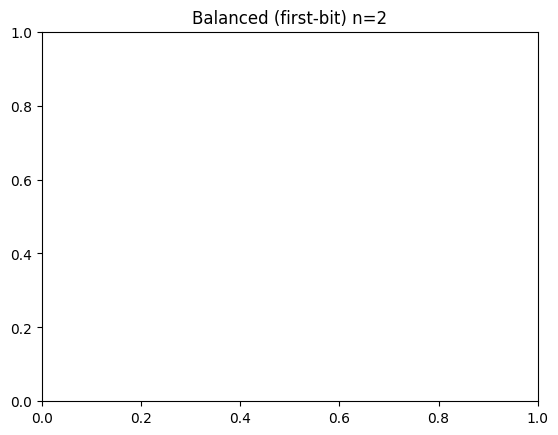

✅ Not all zeros => Function is BALANCED

DEUTSCH-JOZSA, n = 4 inputs — Balanced (first-bit) oracle
Circuit depth: 5
     ┌───┐          ┌───┐      ┌─┐
q_0: ┤ H ├───────■──┤ H ├──────┤M├
     ├───┤┌───┐  │  └┬─┬┘      └╥┘
q_1: ┤ H ├┤ H ├──┼───┤M├────────╫─
     ├───┤├───┤  │   └╥┘ ┌─┐    ║ 
q_2: ┤ H ├┤ H ├──┼────╫──┤M├────╫─
     ├───┤├───┤  │    ║  └╥┘┌─┐ ║ 
q_3: ┤ H ├┤ H ├──┼────╫───╫─┤M├─╫─
     ├───┤├───┤┌─┴─┐  ║   ║ └╥┘ ║ 
q_4: ┤ X ├┤ H ├┤ X ├──╫───╫──╫──╫─
     └───┘└───┘└───┘  ║   ║  ║  ║ 
c: 4/═════════════════╩═══╩══╩══╩═
                      1   2  3  0 
Counts: {'0001': 1024}


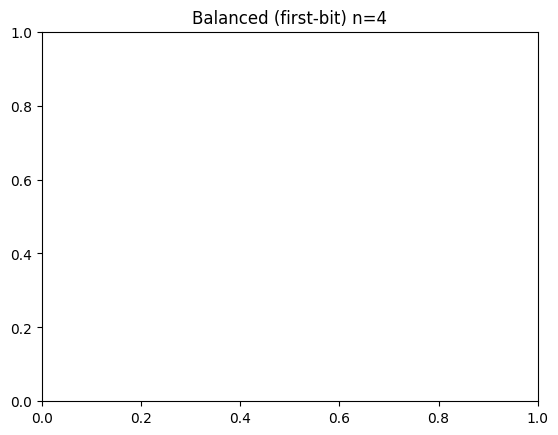

✅ Not all zeros => Function is BALANCED

DEUTSCH-JOZSA, n = 5 inputs — Balanced (first-bit) oracle
Circuit depth: 5
     ┌───┐          ┌───┐         ┌─┐
q_0: ┤ H ├───────■──┤ H ├─────────┤M├
     ├───┤┌───┐  │  └┬─┬┘         └╥┘
q_1: ┤ H ├┤ H ├──┼───┤M├───────────╫─
     ├───┤├───┤  │   └╥┘ ┌─┐       ║ 
q_2: ┤ H ├┤ H ├──┼────╫──┤M├───────╫─
     ├───┤├───┤  │    ║  └╥┘┌─┐    ║ 
q_3: ┤ H ├┤ H ├──┼────╫───╫─┤M├────╫─
     ├───┤├───┤  │    ║   ║ └╥┘┌─┐ ║ 
q_4: ┤ H ├┤ H ├──┼────╫───╫──╫─┤M├─╫─
     ├───┤├───┤┌─┴─┐  ║   ║  ║ └╥┘ ║ 
q_5: ┤ X ├┤ H ├┤ X ├──╫───╫──╫──╫──╫─
     └───┘└───┘└───┘  ║   ║  ║  ║  ║ 
c: 5/═════════════════╩═══╩══╩══╩══╩═
                      1   2  3  4  0 
Counts: {'00001': 1024}


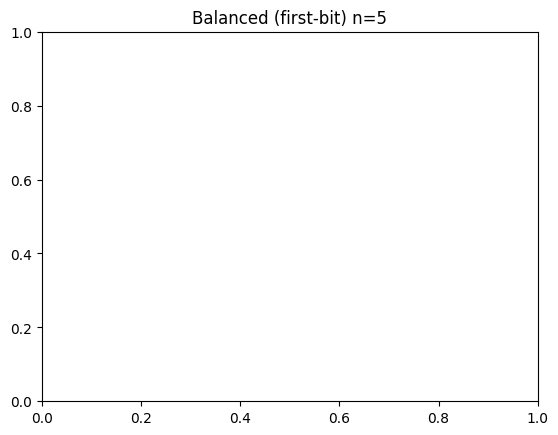

✅ Not all zeros => Function is BALANCED

Demo: arbitrary-half balanced oracle (n=3)
Circuit depth: 14
     ┌───┐          ┌───┐          ┌───┐          ┌───┐     ┌───┐┌───┐   ┌─┐
q_0: ┤ H ├───────■──┤ X ├───────■──┤ X ├───────■──┤ X ├──■──┤ X ├┤ H ├───┤M├
     ├───┤┌───┐  │  ├───┤┌───┐  │  ├───┤┌───┐  │  ├───┤  │  ├───┤└┬─┬┘   └╥┘
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├──■──┤ H ├─┤M├─────╫─
     ├───┤├───┤  │  ├───┤└───┘  │  └───┘└───┘  │  └───┘  │  ├───┤ └╥┘ ┌─┐ ║ 
q_2: ┤ H ├┤ X ├──■──┤ X ├───────■──────────────■─────────■──┤ H ├──╫──┤M├─╫─
     ├───┤├───┤┌─┴─┐└───┘     ┌─┴─┐          ┌─┴─┐     ┌─┴─┐└───┘  ║  └╥┘ ║ 
q_3: ┤ X ├┤ H ├┤ X ├──────────┤ X ├──────────┤ X ├─────┤ X ├───────╫───╫──╫─
     └───┘└───┘└───┘          └───┘          └───┘     └───┘       ║   ║  ║ 
c: 3/══════════════════════════════════════════════════════════════╩═══╩══╩═
                                                                   1   2  0 
Counts: {'101': 234, '100': 293, '011': 239, '010':

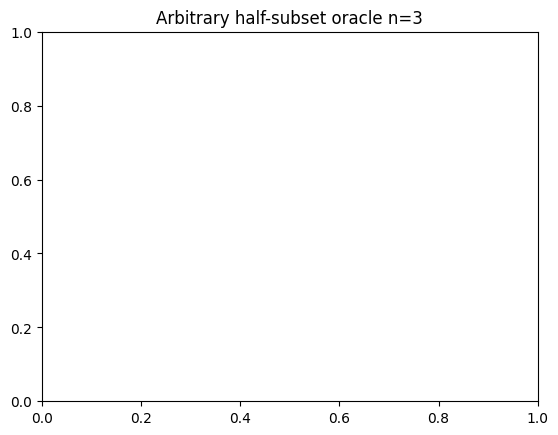

✅ Not all zeros => Function is BALANCED

--- Running with noise model ---
Circuit depth: 5
     ┌───┐          ┌───┐      ┌─┐
q_0: ┤ H ├───────■──┤ H ├──────┤M├
     ├───┤┌───┐  │  └┬─┬┘      └╥┘
q_1: ┤ H ├┤ H ├──┼───┤M├────────╫─
     ├───┤├───┤  │   └╥┘ ┌─┐    ║ 
q_2: ┤ H ├┤ H ├──┼────╫──┤M├────╫─
     ├───┤├───┤  │    ║  └╥┘┌─┐ ║ 
q_3: ┤ H ├┤ H ├──┼────╫───╫─┤M├─╫─
     ├───┤├───┤┌─┴─┐  ║   ║ └╥┘ ║ 
q_4: ┤ X ├┤ H ├┤ X ├──╫───╫──╫──╫─
     └───┘└───┘└───┘  ║   ║  ║  ║ 
c: 4/═════════════════╩═══╩══╩══╩═
                      1   2  3  0 
Counts: {'0000': 26, '0001': 2022}


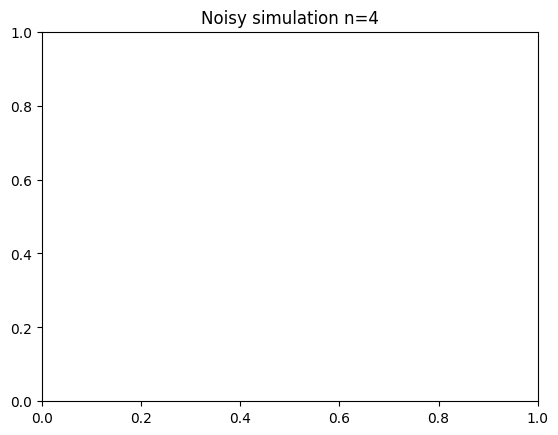

✅ Not all zeros => Function is BALANCED

Printing oracle gate definition for first-bit oracle (n=3):
Oracle gate definition (decomposition):
          
q_0: ──■──
       │  
q_1: ──┼──
       │  
q_2: ──┼──
     ┌─┴─┐
q_3: ┤ X ├
     └───┘


In [13]:
if __name__ == "__main__":
    # TASK 2: run DJ for different n with a balanced oracle that depends on first bit
    demo_various_n()

    # TASK 1: show arbitrary-half oracle for n=3
    print("\nDemo: arbitrary-half balanced oracle (n=3)")
    demo_arbitrary_half_oracle(n=3)

    # TASK 3: Add noise model and observe
    nm = demo_noise_model(n=4)

    # TASK 5: Print oracle gate definition and explain
    print("\nPrinting oracle gate definition for first-bit oracle (n=3):")
    print_oracle_gate_definition(3, oracle_balanced_firstbit)